In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.core.model_engine_mixed import NormativeModelEngineMixed
from MixedEffectsModeling.core.ood_filter import MahalanobisFilter, RangeFilter
from MixedEffectsModeling.core.shash import load_shash_params, shash_correct_matrix
from MixedEffectsModeling.validation.lobo_engine import load_full_data

ZDIR = Path('./Z_scores_mixed')
ZDIR.mkdir(parents=True, exist_ok=True)

%matplotlib inline

In [2]:
# 0. Load production engine + disease covariates/counts (non-HC rows of the same QC-filtered cohort LOBO uses)
engine = NormativeModelEngineMixed.load(config.ENGINE_MIXED_DIR)
gene_names = [g for g in engine.genes if engine.genes[g].ok]

data = load_full_data()
dis_idx = np.where(~data['is_hc'])[0]
X_dis = data['X_raw'][dis_idx]
Y_dis = data['Y'][dis_idx][:, [data['gene_col'][g] for g in gene_names]]
names_dis = data['names'][dis_idx]
batch_dis = data['batch'][dis_idx]
phenotype_dis = data['phenotype'][dis_idx]

print(f"engine genes (ok): {len(gene_names)}")
print(f"disease samples: {len(dis_idx)}")
print(pd.Series(phenotype_dis).value_counts())

engine genes (ok): 19858
disease samples: 913
CAD_HF+               116
CAD_HF-               108
Tuberculosis          103
ME/CFS                 90
Pancreatitis           81
Pancreatic Cancer      74
Pre-eclampsia          62
Liver Cancer           48
Colorectal Cancer      41
Lung Cancer            33
Stomach Cancer         29
Esophagus Cancer       27
MM                     18
Other Cancer           18
HIV                    13
HIV + Tuberculosis     11
ICI-m                  11
ICI-treated Cancer     11
MGUS                    8
Pancreatic Cancer       6
Liver Cirrhosis         5
Name: count, dtype: int64


In [3]:
hc_train_mask = data['is_hc'] & ~np.isin(data['batch'], list(data['small_hc_batches']))
X_hc = data['X_raw'][hc_train_mask]

ood = MahalanobisFilter(percentile=95).fit(X_hc)
mahal_dist = ood.distances(X_dis)
mahal_keep = mahal_dist <= ood.threshold_
rng_filter = RangeFilter(n_out_thr=2).fit(X_hc)
n_out = rng_filter.n_out(X_dis)
range_keep = rng_filter.mask(X_dis)

ood_keep = mahal_keep & range_keep

summary = (pd.DataFrame({'phenotype': phenotype_dis, 'keep': ood_keep})
          .groupby('phenotype')['keep']
          .agg(n_total='size', n_kept='sum')
          .assign(pct_removed=lambda d: (1 - d['n_kept'] / d['n_total']) * 100)
          .sort_values('pct_removed', ascending=False))
print(f"Mahalanobis P95 threshold: {ood.threshold_:.2f}  (flagged {int((~mahal_keep).sum())})")
print(f"Range filter (>={rng_filter.n_out_thr} axes outside HC p1-p99): flagged {int((~range_keep).sum())}")
print(f"combined: kept {ood_keep.sum()}/{len(ood_keep)} ({(~ood_keep).mean()*100:.1f}% flagged OOD)")
print(summary.to_string())

Mahalanobis P95 threshold: 5.21  (flagged 50)
Range filter (>=2 axes outside HC p1-p99): flagged 54
combined: kept 833/913 (8.8% flagged OOD)
                    n_total  n_kept  pct_removed
phenotype                                       
Pancreatic Cancer         6       2    66.666667
Stomach Cancer           29      21    27.586207
Lung Cancer              33      26    21.212121
Liver Cirrhosis           5       4    20.000000
ICI-treated Cancer       11       9    18.181818
Colorectal Cancer        41      34    17.073171
Liver Cancer             48      40    16.666667
CAD_HF+                 116     101    12.931034
Other Cancer             18      16    11.111111
CAD_HF-                 108      97    10.185185
HIV + Tuberculosis       11      10     9.090909
ICI-m                    11      10     9.090909
Esophagus Cancer         27      25     7.407407
Pre-eclampsia            62      58     6.451613
MM                       18      17     5.555556
Pancreatic Cancer        

21 phenotypes, 913 disease samples scored
                    n_total  n_kept
phenotype                          
Pancreatic Cancer         6       2
Stomach Cancer           29      21
Lung Cancer              33      26
Liver Cirrhosis           5       4
ICI-treated Cancer       11       9
Colorectal Cancer        41      34
Liver Cancer             48      40
CAD_HF+                 116     101
Other Cancer             18      16
CAD_HF-                 108      97
HIV + Tuberculosis       11      10
ICI-m                    11      10
Esophagus Cancer         27      25
Pre-eclampsia            62      58
MM                       18      17
Pancreatic Cancer        74      72
Pancreatitis             81      79
Tuberculosis            103     101
HIV                      13      13
MGUS                      8       8
ME/CFS                   90      90


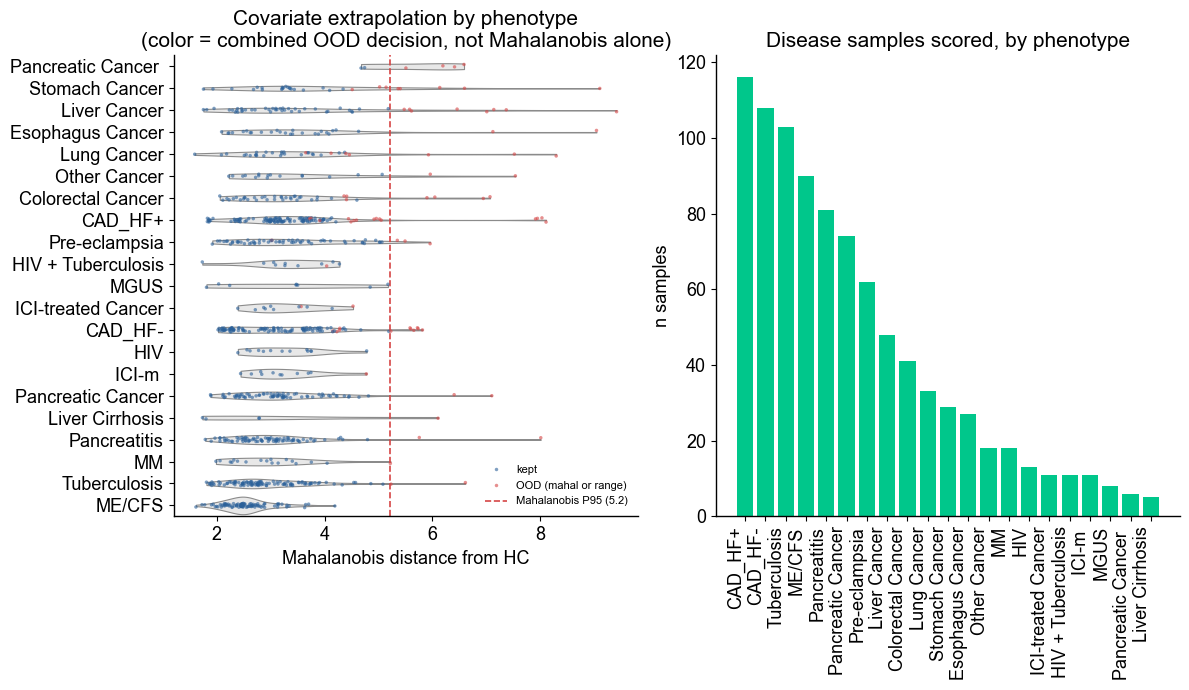

In [4]:
print(f"{summary.shape[0]} phenotypes, {len(phenotype_dis)} disease samples scored")
print(summary[['n_total', 'n_kept']].to_string())

vio = pd.DataFrame({'phenotype': phenotype_dis, 'mahal_dist': mahal_dist, 'n_out': n_out,
                    'flag': np.where(ood_keep, 'kept', 'OOD (mahal or range)')})
order_mahal = vio.groupby('phenotype')['mahal_dist'].mean().sort_values(ascending=False).index
order_count = summary.sort_values('n_total', ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# violin shows the Mahalanobis axis, but point color is the COMBINED decision (mahal OR range) --
# a point can sit left of the Mahalanobis line and still be red if the range filter caught it
sns.violinplot(data=vio, y='phenotype', x='mahal_dist', order=order_mahal,
               color='#e8e8e8', orient='h', cut=0, inner=None, linewidth=0.8, ax=axes[0])
sns.stripplot(data=vio, y='phenotype', x='mahal_dist', order=order_mahal, hue='flag',
              hue_order=['kept', 'OOD (mahal or range)'], palette=['#2a6099', '#d64545'],
              orient='h', size=2.5, alpha=0.6, jitter=True, ax=axes[0])
axes[0].axvline(ood.threshold_, color='#d64545', ls='--', lw=1.2, label=f'Mahalanobis P95 ({ood.threshold_:.1f})')
axes[0].set_xlabel('Mahalanobis distance from HC')
axes[0].set_ylabel('')
axes[0].set_title('Covariate extrapolation by phenotype\n(color = combined OOD decision, not Mahalanobis alone)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, frameon=False, fontsize=8, loc='lower right')

axes[1].bar(range(len(order_count)), summary.loc[order_count, 'n_total'], color='#00C78B')
axes[1].set_xticks(range(len(order_count)))
axes[1].set_xticklabels(order_count, rotation=90, ha='right')
axes[1].set_ylabel('n samples')
axes[1].set_title('Disease samples scored, by phenotype')

plt.tight_layout()
fig.savefig(ZDIR / 'phenotype_summary.png', bbox_inches='tight')

In [5]:
# 1. Score (raw RQR) -- cache-first
Z_CAP = 10.0  # |Z| beyond this is already p~1e-23 -- clip only tames the axis, doesn't change BH calls
Z_PATH = ZDIR / 'Z_disease.npy'
GENES_PATH = ZDIR / 'gene_names.pkl'
META_PATH = ZDIR / 'sample_meta.csv'

if Z_PATH.exists():
    Z = np.load(Z_PATH)
else:
    Z = np.clip(engine.score(X_dis, Y_dis, gene_names=gene_names), -Z_CAP, Z_CAP)
    np.save(Z_PATH, Z)
    with open(GENES_PATH, 'wb') as f:
        pickle.dump(gene_names, f)

pd.DataFrame({'sample': names_dis, 'batch': batch_dis, 'phenotype': phenotype_dis,
             'ood_keep': ood_keep, 'mahal_dist': mahal_dist, 'n_out': n_out}).to_csv(META_PATH, index=False)

print(f"Z shape: {Z.shape}, finite frac: {np.isfinite(Z).mean():.4f}, max |Z|: {np.nanmax(np.abs(Z)):.2f}")

Z shape: (913, 19858), finite frac: 1.0000, max |Z|: 7.94


In [6]:
# 2. SHASH-correct -- cache-first
Z_SHASH_PATH = ZDIR / 'Z_disease_shash.npy'

if Z_SHASH_PATH.exists():
    Z_shash = np.load(Z_SHASH_PATH)
else:
    shash_params = load_shash_params(config.ENGINE_MIXED_DIR / 'training_summary.csv')  # engine's own in-sample SHASH fit, see model_engine_mixed.NormativeModelEngineMixed.fit_shash
    Z_shash = shash_correct_matrix(np.nan_to_num(Z, nan=0.0, posinf=10.0, neginf=-10.0), gene_names, shash_params)
    Z_shash = np.clip(Z_shash, -Z_CAP, Z_CAP)
    Z_shash[~np.isfinite(Z)] = np.nan
    np.save(Z_SHASH_PATH, Z_shash)

print(f"Z_shash shape: {Z_shash.shape}")
print(f"mean |Z| raw vs shash: {np.nanmean(np.abs(Z)):.4f} vs {np.nanmean(np.abs(Z_shash)):.4f}")
print(f"max |Z_shash|: {np.nanmax(np.abs(Z_shash)):.2f}")

Z_shash shape: (913, 19858)
mean |Z| raw vs shash: 0.8524 vs 0.8640
max |Z_shash|: 10.00


In [7]:
from scipy.stats import norm

from MixedEffectsModeling.core.calibration import bh_fdr_reject
FDR_Q = 0.05

# per-sample BH-significant gene count + critical p-value, cache-first
SIG_PATH = ZDIR / 'sample_bh_sig.csv'
if SIG_PATH.exists():
    sig_df = pd.read_csv(SIG_PATH)
else:
    p_all = 2 * norm.sf(np.abs(Z_shash))
    n_sig = np.zeros(len(names_dis), dtype=int)
    p_thr = np.full(len(names_dis), np.nan)
    for i in range(len(names_dis)):
        row = p_all[i]
        row = row[np.isfinite(row)]
        if len(row) == 0:
            continue
        reject = bh_fdr_reject(row, q=FDR_Q)
        n_sig[i] = int(reject.sum())
        if reject.any():
            p_thr[i] = float(row[reject].max())
    sig_df = pd.DataFrame({'sample': names_dis, 'phenotype': phenotype_dis, 'ood_keep': ood_keep,
                           'n_sig': n_sig, 'p_thr': p_thr})
    sig_df.to_csv(SIG_PATH, index=False)

top = sig_df[sig_df['ood_keep']].sort_values('n_sig', ascending=False).head(20)
print(top[['sample', 'phenotype', 'n_sig', 'p_thr']].to_string(index=False))

     sample         phenotype  n_sig    p_thr
SRR14506728      Liver Cancer   1448 0.003646
SRR14506735      Liver Cancer   1305 0.003281
SRR14506777    Stomach Cancer   1058 0.002654
SRR14506802 Colorectal Cancer    941 0.002361
SRR33475188            ICI-m     904 0.002249
SRR33475193            ICI-m     818 0.002059
SRR14506707       Lung Cancer    778 0.001955
SRR14506768    Stomach Cancer    767 0.001921
SRR14506801 Colorectal Cancer    700 0.001760
SRR15619011                MM    691 0.001733
SRR14506706       Lung Cancer    655 0.001642
SRR29803958 Pancreatic Cancer    594 0.001492
SRR33475189            ICI-m     577 0.001452
SRR29804042 Pancreatic Cancer    397 0.000993
SRR14506705       Lung Cancer    389 0.000977
SRR15619009                MM    380 0.000952
SRR14506720       Lung Cancer    373 0.000937
SRR14506693       Lung Cancer    372 0.000924
SRR28476480               HIV    368 0.000915
SRR14506725      Liver Cancer    352 0.000883


In [8]:
import scanpy as sc

CHROM_ORDER = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY', 'chrM']
chrom_rank = {c: i for i, c in enumerate(CHROM_ORDER)}

var = sc.read_h5ad(config.H5AD_PATH, backed='r').var.loc[gene_names, ['Chromosome']].copy()
var['rank'] = var['Chromosome'].map(chrom_rank).astype(float).fillna(len(CHROM_ORDER))
var = var.sort_values('rank', kind='stable')  # stable: keeps var's own (genomic-proxy) order within a chromosome
var['x'] = range(len(var))

gene_x = var['x'].to_dict()
x_pos = np.array([gene_x[g] for g in gene_names])
chrom_of = var['Chromosome']
tick_df = var.groupby('Chromosome')['x'].median().reindex([c for c in CHROM_ORDER if c in var['Chromosome'].values])
tick_x = tick_df.values
tick_lab = [c.replace('chr', '') for c in tick_df.index]

/tmp/ipykernel_421861/2890160353.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tick_df = var.groupby('Chromosome')['x'].median().reindex([c for c in CHROM_ORDER if c in var['Chromosome'].values])


In [9]:
import json

REF_DIR = Path('Benchmark/disease_reference')
MARKER_TOPN = 500
MARKER_SCORE_FLOOR = 0.01

sym_of = sc.read_h5ad(config.H5AD_PATH, backed='r').var['GeneName'].reindex(gene_names)
sym2cols = {}
for j, sym in enumerate(sym_of.values):
    sym2cols.setdefault(sym, []).append(j)

pheno_markers = {}
pheno_scores = {}  # sym -> OT association score, drives both label ranking and sample ranking below
for f in REF_DIR.glob('*.json'):
    rec = json.load(open(f))
    if rec['phenotype'] == 'MGUS':  # OT association pool too thin (22 genes) for any panel size
        continue
    ranked = sorted(rec['genes'], key=lambda gs: -gs[1])
    floored = [g for g, s in ranked if s >= MARKER_SCORE_FLOOR]
    genes = set(floored[:MARKER_TOPN]) | set(rec.get('supplement', {}).get('genes', []))
    pheno_markers[rec['phenotype']] = genes
    pheno_scores[rec['phenotype']] = dict(rec['genes'])

p_all = 2 * norm.sf(np.abs(Z_shash))
phenotype_stripped = pd.Series(phenotype_dis).str.strip().values
p_thr_of = sig_df.set_index('sample')['p_thr']
n_sig_of = sig_df.set_index('sample')['n_sig']  # genome-wide BH-significant gene count, not just markers

rows = []
for i, (name, ph) in enumerate(zip(names_dis, phenotype_stripped)):
    markers = pheno_markers.get(ph)
    scores = pheno_scores.get(ph, {})
    p_thr = p_thr_of.get(name, np.nan)
    marker_cols = sorted({j for sym in (markers or []) for j in sym2cols.get(sym, [])})
    hit_syms = ([] if not marker_cols or not np.isfinite(p_thr)
                else sorted({sym_of.iloc[j] for j in marker_cols if p_all[i, j] <= p_thr}))
    hit_scores = [scores.get(s, 0.0) for s in hit_syms]
    rows.append((name, ph, ood_keep[i], len(marker_cols), len(hit_syms), ';'.join(hit_syms), int(n_sig_of.get(name, 0)),
                float(np.sum(hit_scores)), float(np.mean(hit_scores)) if hit_scores else 0.0))

marker_df = pd.DataFrame(rows, columns=['sample', 'phenotype', 'ood_keep', 'n_markers_tested',
                                        'n_markers_sig', 'marker_genes_sig', 'n_sig_genome',
                                        'marker_score_sum', 'marker_score_mean'])
marker_df['frac_markers_sig'] = marker_df['n_markers_sig'] / marker_df['n_markers_tested'].replace(0, np.nan)
marker_df.to_csv(ZDIR / 'sample_marker_hits.csv', index=False)

print(marker_df.groupby('phenotype').agg(
    n_samples=('sample', 'size'), n_markers=('n_markers_tested', 'first'),
    mean_n_sig_genome=('n_sig_genome', 'mean'), mean_frac_sig=('frac_markers_sig', 'mean')).to_string())
marker_df[marker_df['ood_keep'] & (marker_df['n_markers_tested'] > 0)].sort_values(
    'marker_score_sum', ascending=False).head(15)

                    n_samples  n_markers  mean_n_sig_genome  mean_frac_sig
phenotype                                                                 
CAD_HF+                   116          0          31.879310            NaN
CAD_HF-                   108          0          25.342593            NaN
Colorectal Cancer          41        501         202.682927       0.016747
Esophagus Cancer           27        499          39.629630       0.001559
HIV                        13        501         107.692308       0.007984
HIV + Tuberculosis         11        485          30.272727       0.002812
ICI-m                      11          0         502.545455            NaN
ICI-treated Cancer         11          0          54.181818            NaN
Liver Cancer               48        500         355.458333       0.022542
Liver Cirrhosis             5        497         284.600000       0.012072
Lung Cancer                33        502         307.454545       0.016419
ME/CFS                   

,sample,phenotype,ood_keep,n_markers_tested,n_markers_sig,marker_genes_sig,n_sig_genome,marker_score_sum,marker_score_mean,frac_markers_sig
61,SRR14506728,Liver Cancer,True,500,77,ABI1;ARNT;ASXL1;ATM;BCL10;BRD3;BRD4;BRIP1;BTG1...,1448,26.3347,0.342009,0.154000
114,SRR14506802,Colorectal Cancer,True,501,35,ASXL1;BAX;BRCA1;BTG1;CCNB1IP1;CDKN1B;CIITA;DNM...,941,16.6052,0.474434,0.069860
113,SRR14506801,Colorectal Cancer,True,501,34,BTG1;CASP8;CHEK2;CIITA;DDX3X;DNMT3A;ELF4;ERG;F...,700,16.4597,0.484109,0.067864
585,SRR29803958,Pancreatic Cancer,True,500,37,ABI1;AMER1;BCL2;BRD4;BTK;CALR;CUX1;CYLD;DDX3X;...,594,14.0312,0.379222,0.074000
93,SRR14506777,Stomach Cancer,True,502,24,AFF4;ALK;APC;ATF1;ATM;CDKN2C;CDX2;CYLD;FBXO11;...,1058,10.6639,0.444329,0.047809
86,SRR14506768,Stomach Cancer,True,502,24,ATM;BAP1;BCORL1;CDC73;CDKN2C;CIC;DPYD;DROSHA;F...,767,10.5538,0.439742,0.047809
67,SRR14506735,Liver Cancer,True,500,27,ALK;APC;ARID1B;BCORL1;BLM;CDKN2A;CDKN2C;FOXP1;...,1305,9.9687,0.369211,0.054000
158,SRR15619011,MM,True,499,28,AKT2;ATRX;BAK1;BARD1;BRCA1;BUB1B;CCNB1IP1;CD79...,691,9.5718,0.341850,0.056112
42,SRR14506706,Lung Cancer,True,502,17,CACNA1D;CARS1;CHEK2;CIC;CXCR4;ERCC4;GART;MRTFA...,655,9.2836,0.546094,0.033865
41,SRR14506705,Lung Cancer,True,502,15,ATF1;ATRX;DCBLD1;DROSHA;IDH2;MYB;NDRG1;NSD3;PO...,389,7.4469,0.496460,0.029880


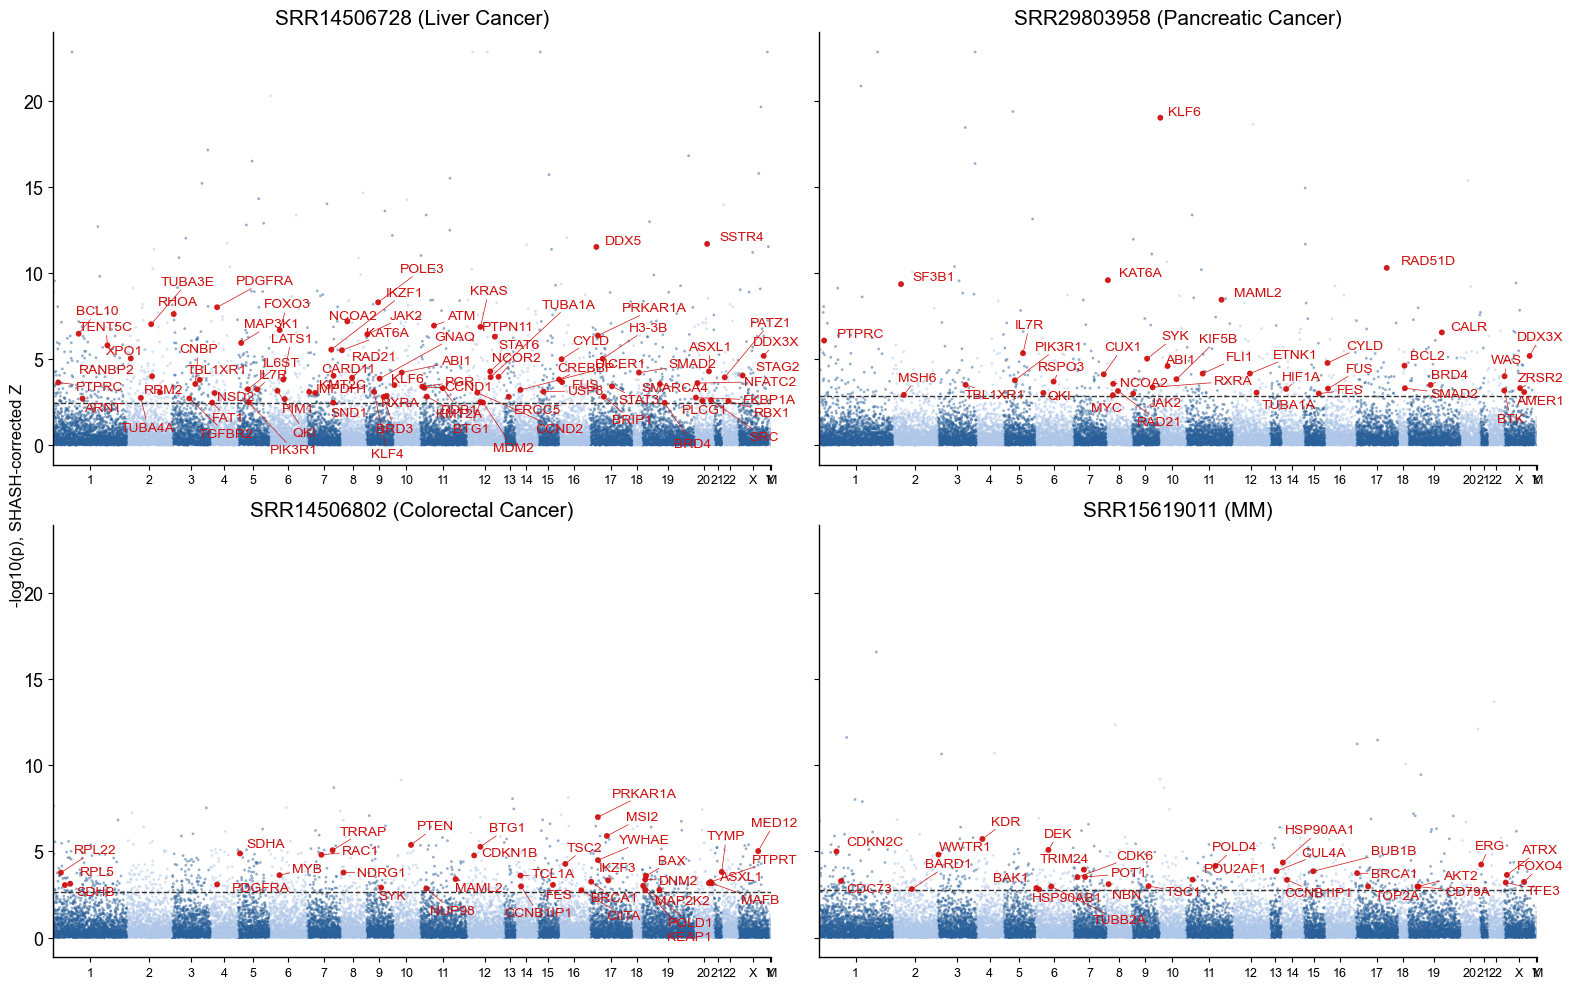

In [10]:
# alternating chromosome colors, index-aligned to gene_names order (= Z_shash columns)
from adjustText import adjust_text

chrom_color = np.where(chrom_of.map(chrom_rank).astype(float).reindex(gene_names).fillna(0).values % 2 == 0, '#2a6099', '#aec6e8')

name2row = {n: i for i, n in enumerate(names_dis)}

top4 = marker_df[marker_df['ood_keep'] & (marker_df['n_markers_tested'] > 0)].sort_values(
    'frac_markers_sig', ascending=False).iloc[[0, 1, 2, 4]]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()
for ax, (_, row) in zip(axes, top4.iterrows()):
    i = name2row[row['sample']]
    z = Z_shash[i]
    p = 2 * norm.sf(np.abs(np.nan_to_num(z)))
    p[~np.isfinite(z)] = np.nan
    neglog10p = -np.log10(np.clip(p, 1e-300, 1))

    markers = pheno_markers.get(row['phenotype'], set())
    marker_cols = sorted({j for sym in markers for j in sym2cols.get(sym, [])})
    p_thr = p_thr_of.get(row['sample'], np.nan)
    is_marker = np.zeros(len(gene_names), dtype=bool)
    is_marker[marker_cols] = True
    is_hit = is_marker & np.isfinite(p_thr) & (p <= p_thr)

    ax.scatter(x_pos[~is_hit], neglog10p[~is_hit], c=chrom_color[~is_hit], s=4, alpha=0.5, edgecolors='none')
    ax.scatter(x_pos[is_hit], neglog10p[is_hit], c="#cf0f0f", s=18, alpha=0.95, edgecolors='none', zorder=3)
    texts = [ax.text(x_pos[j], neglog10p[j], sym_of.iloc[j], color='#cf0f0f')
             for j in np.where(is_hit)[0]]
    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='#cf0f0f', lw=0.5))
    if np.isfinite(p_thr):
        ax.axhline(-np.log10(p_thr), color='#333333', ls='--', lw=1)
    ax.set_xticks(tick_x)
    ax.set_xticklabels(tick_lab, fontsize=9)
    ax.set_title(f"{row['sample']} ({row['phenotype']})")
    ax.set_xlim(0, len(gene_names))
fig.supylabel('-log10(p), SHASH-corrected Z')
plt.tight_layout()
fig.savefig(ZDIR / 'manhattan_marker_top4.png', bbox_inches='tight')

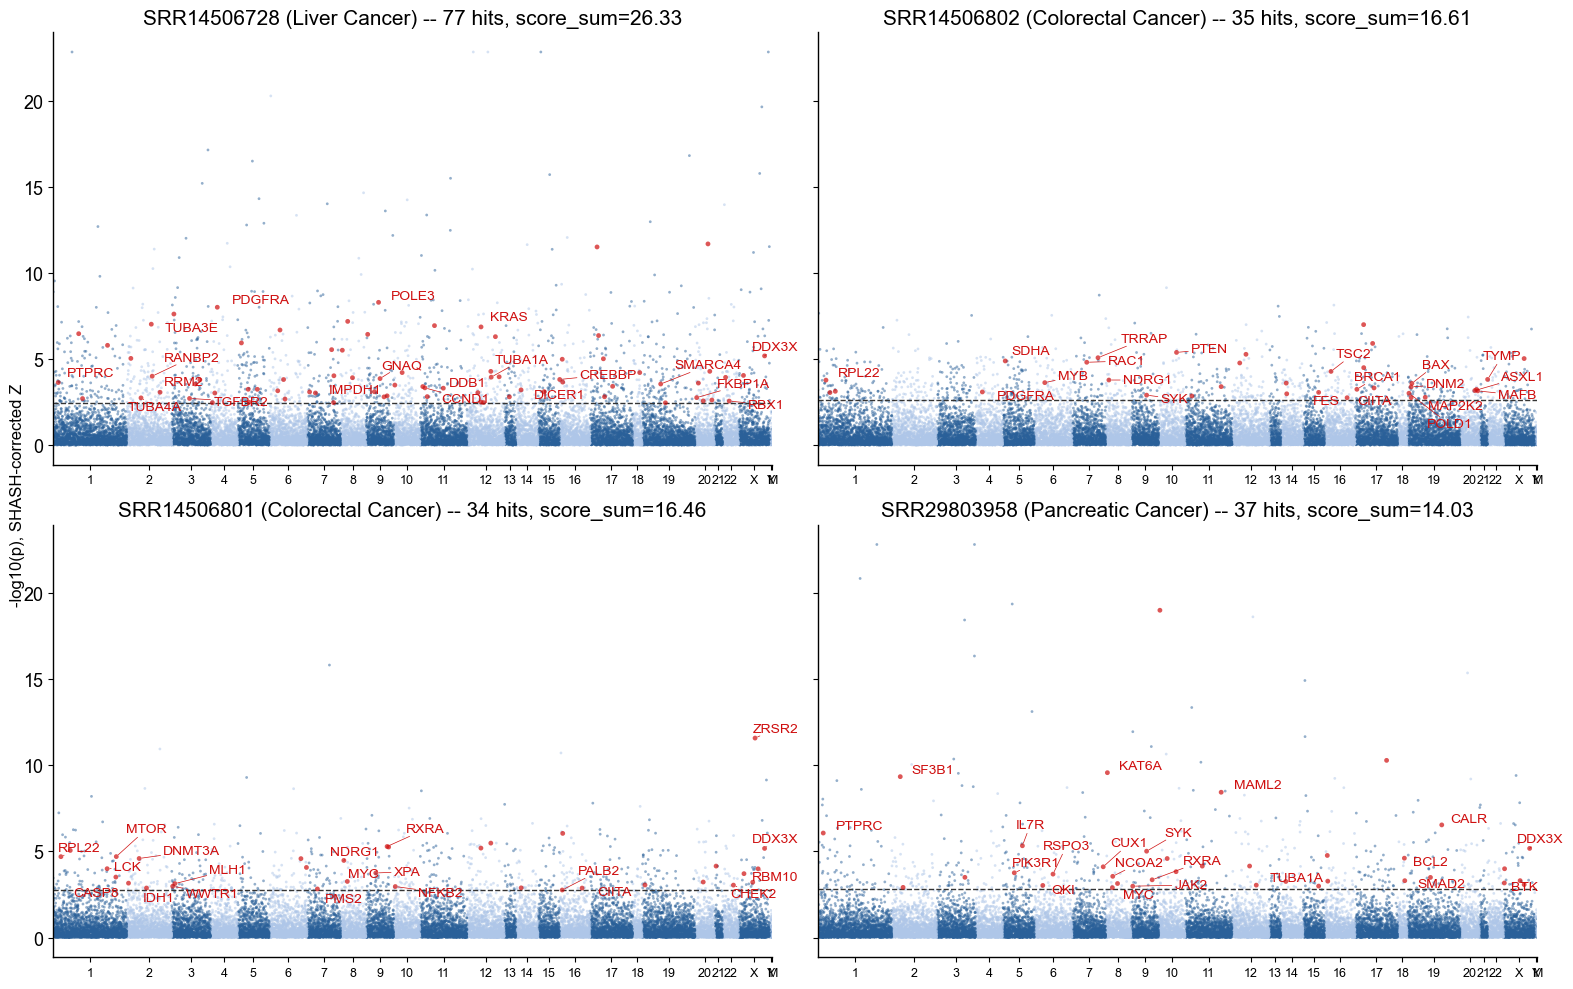

In [11]:
# rank samples by summed OT association score of their significant marker hits, not raw hit count --
# a sample with 10 hits on top-ranked disease genes should outrank one with 100 hits on tail-ranked genes
N_CURATED = 4
LABEL_TOPK = 20  # cap notated genes per panel by DB association score, else dense hit sets overlap

curated = marker_df[marker_df['ood_keep'] & (marker_df['n_markers_tested'] > 0)].sort_values(
    'marker_score_sum', ascending=False).head(N_CURATED)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()
for ax, (_, row) in zip(axes, curated.iterrows()):
    i = name2row[row['sample']]
    z = Z_shash[i]
    p = 2 * norm.sf(np.abs(np.nan_to_num(z)))
    p[~np.isfinite(z)] = np.nan
    neglog10p = -np.log10(np.clip(p, 1e-300, 1))

    markers = pheno_markers.get(row['phenotype'], set())
    marker_cols = sorted({j for sym in markers for j in sym2cols.get(sym, [])})
    p_thr = p_thr_of.get(row['sample'], np.nan)
    is_marker = np.zeros(len(gene_names), dtype=bool)
    is_marker[marker_cols] = True
    is_hit = is_marker & np.isfinite(p_thr) & (p <= p_thr)

    scores = pheno_scores.get(row['phenotype'], {})
    hit_cols = np.where(is_hit)[0]
    label_cols = sorted(hit_cols, key=lambda j: -scores.get(sym_of.iloc[j], 0))[:LABEL_TOPK]

    ax.scatter(x_pos[~is_hit], neglog10p[~is_hit], c=chrom_color[~is_hit], s=4, alpha=0.5, edgecolors='none')
    ax.scatter(x_pos[is_hit], neglog10p[is_hit], c="#cf0f0f", s=12, alpha=0.7, edgecolors='none', zorder=3)
    texts = [ax.text(x_pos[j], neglog10p[j], sym_of.iloc[j], color='#cf0f0f') for j in label_cols]
    if texts:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='#cf0f0f', lw=0.5))
    if np.isfinite(p_thr):
        ax.axhline(-np.log10(p_thr), color='#333333', ls='--', lw=1)
    ax.set_xticks(tick_x)
    ax.set_xticklabels(tick_lab, fontsize=9)
    ax.set_title(f"{row['sample']} ({row['phenotype']}) -- {len(hit_cols)} hits, score_sum={row['marker_score_sum']:.2f}")
    ax.set_xlim(0, len(gene_names))
fig.supylabel('-log10(p), SHASH-corrected Z')
plt.tight_layout()
fig.savefig(ZDIR / 'manhattan_marker_curated.png', bbox_inches='tight')

In [ ]:
import h5py
from scipy.stats import kruskal, mannwhitneyu, spearmanr

NSIG_SRC = Path(config.LOBO_MIXED_DIR) / 'lobo_nsig.csv'
assert NSIG_SRC.exists(), f'run section 5 of 2_lobo_validation.ipynb first ({NSIG_SRC} missing)'
BATCH = 'Moore et al._Batch_1'
NEOPLASTIC = ['HC', 'IPMN', 'Islet Cell Tumor', 'PDAC']

with h5py.File(config.H5AD_PATH, 'r') as h:
    dec = lambda a: np.array([x.decode('utf-8', 'replace') if isinstance(x, bytes) else str(x) for x in a])
    g = h['obs/Stage/Condition']
    stage = pd.Series(pd.Categorical.from_codes(g['codes'][()], dec(g['categories'][()])).astype(str),
                      index=dec(h['obs/_index'][()]))

sev = pd.read_csv(NSIG_SRC).query('batch == @BATCH').copy()
sev['group'] = np.where(sev['is_hc'], 'HC', sev['sample'].map(stage))
neo = sev[sev['group'].isin(NEOPLASTIC)].copy()
neo['rank'] = neo['group'].map({k: i for i, k in enumerate(NEOPLASTIC)})

rho, p_rho = spearmanr(neo['rank'], neo['n_sig'])
kw = kruskal(*[d['n_sig'].values for _, d in neo.groupby('group')]).pvalue
pan = sev.loc[sev['group'] == 'Pancreatitis', 'n_sig']
hc = sev.loc[sev['group'] == 'HC', 'n_sig']
p_pan = mannwhitneyu(pan, hc, alternative='greater').pvalue

print(sev.groupby('group')['n_sig'].agg(n='size', median='median', mean='mean')
      .reindex(NEOPLASTIC + ['Pancreatitis']).to_string(float_format=lambda v: f'{v:.1f}'))
print(f"\nneoplastic severity: Spearman rho={rho:+.3f} p={p_rho:.2e} (n={len(neo)}), Kruskal p={kw:.2e}")
print(f"pancreatitis vs HC: Mann-Whitney p={p_pan:.2e}")
print(f"HC outlier: max n_sig={hc.max()} (next {sorted(hc.values)[-2]}) -- median-based summaries used throughout")
order = NEOPLASTIC + ['Pancreatitis']
labels = ['Healthy control\n(LOBO)', 'IPMN\n(benign)', 'Islet cell\ntumour', 'PDAC', 'Acute\npancreatitis']
colors = ['#dce6f2', '#a8c4e0', '#5b8bc0', '#2a6099', '#00C78B']
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

sns.boxplot(
    data=sev[sev['group'].isin(order)], 
    x='group', y='n_sig', order=order,
    palette=colors, ax=ax, width=0.45,
    fliersize=0, boxprops=dict(alpha=0.75, linewidth=1.1),
    medianprops=dict(color='black', linewidth=1.8)
)

medians = sev[sev['group'].isin(NEOPLASTIC)].groupby('group')['n_sig'].median().reindex(NEOPLASTIC)

ax.plot(
    range(len(NEOPLASTIC)), medians.values, 
    color='#d90429', linestyle='--', marker='o', 
    linewidth=2, markersize=6, label='Neoplastic Median Trend'
)

ax.axvline(3.5, color='#999999', linestyle=':', linewidth=1.2)

stats_box_text = (
    r"$\bf{Neoplastic\ Gradient}$" "\n"
    f"Spearman $\\rho$: {rho:+.3f}\n"
    f"Spearman $p$: {p_rho:.2e}\n"
    f"Kruskal $p$: {kw:.2e}\n\n"
    r"$\bf{Reference\ Comparison}$" "\n"
    f"Pancreatitis vs HC $p$: {p_pan:.2e}"
)

ax.text(
    0.03, 0.95, stats_box_text, transform=ax.transAxes,
    fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc')
)

ax.set_yscale('symlog')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(labels)
ax.set_ylabel('BH-significant genes per sample ($q=0.05$)')
ax.set_xlabel('')

ax.legend(loc='upper right', frameon=True)
ax.set_ylim(bottom=-1, top=sev['n_sig'].max() * 1.1)
sns.despine(top=True, right=True)
plt.tight_layout()

fig.savefig(ZDIR / 'severity_gradient.png', bbox_inches='tight', dpi=300)

## 6. FDR threshold sweep: per-sample significant gene counts at q=0.05/0.10/0.15/0.20

Rationale: `Benchmark/FDR_THRESHOLD_RATIONALE.md`. q=0.05 stays the confirmatory tier (only one compared against DESeq2 in `5_deseq2_group_comparison.ipynb`); q=0.10-0.20 is a discovery/candidate tier, reported here per-phenotype so relaxed-threshold counts are visible without being cited as evidence of method superiority.

In [13]:
QS = [0.05, 0.10, 0.15, 0.20]
SWEEP_SUMMARY_PATH = ZDIR / 'fdr_threshold_sweep_summary.csv'

if SWEEP_SUMMARY_PATH.exists():
    sweep_summary = pd.read_csv(SWEEP_SUMMARY_PATH)
else:
    p_all = 2 * norm.sf(np.abs(Z_shash))
    summary_rows = []
    for q in QS:
        tag = '' if q == FDR_Q else f'_q{q:g}'.replace('.', '')
        path = ZDIR / f'sample_bh_sig{tag}.csv'
        if path.exists():
            df_q = pd.read_csv(path)
        else:
            n_sig_q = np.zeros(len(names_dis), dtype=int)
            for i in range(len(names_dis)):
                row = p_all[i]
                row = row[np.isfinite(row)]
                if len(row) == 0:
                    continue
                n_sig_q[i] = int(bh_fdr_reject(row, q=q).sum())
            df_q = pd.DataFrame({'sample': names_dis, 'phenotype': phenotype_dis,
                                 'ood_keep': ood_keep, 'n_sig': n_sig_q})
            df_q.to_csv(path, index=False)
        g = (df_q[df_q.ood_keep].groupby('phenotype')['n_sig']
             .agg(median='median', mean='mean', max='max').reset_index())
        g['q'] = q
        summary_rows.append(g)
    sweep_summary = pd.concat(summary_rows, ignore_index=True)
    sweep_summary.to_csv(SWEEP_SUMMARY_PATH, index=False)

sweep_summary

,phenotype,median,mean,max,q
0,CAD_HF+,2104.0,2063.465347,2556,0.05
1,CAD_HF-,2075.0,2056.556701,2684,0.05
2,Colorectal Cancer,2107.0,2113.235294,3301,0.05
3,Esophagus Cancer,2216.0,2250.800000,3017,0.05
4,HIV,2710.0,2557.692308,2955,0.05
...,...,...,...,...,...
79,Pancreatic Cancer,6330.5,6330.500000,6387,0.20
80,Pancreatitis,5605.0,5632.227848,6570,0.20
81,Pre-eclampsia,5576.0,5362.448276,6011,0.20
82,Stomach Cancer,5047.0,5247.904762,6804,0.20
